Sample Texts from Dataset:
Sample 1: Was ist nur mit diesem Scheißland passiert? Alle werden kollektiv bekloppt und teilen Querdenen-Stuss. Erst meinen "Klatschen für die Pflegekräfte" wäre hilfreich und jetzt allen Pflegern und Medizinern so ins Gesicht spucken. Schämt euch!#allenichtganzdicht #allesdichtmachen
Sample 2:   haben schlimme Fehler begangen. Sowohl bei den Obduktionen als auch bei der Impfstoffzulassung etc. Aber gerade am Beispiel Püschel: Was haben die Querdenker draus gemacht? Die Patienten starben an Thrombosen und nicht an Covid. So dumm muss man schon sein...
Sample 3:  Ich denke oft noch an den Fürsten aus Regensburg zurück...der bekam in null komma nix seine Transplantationen.Ein Schelm wer schlechtes dabei denkt
Sample 4: Auch durch eure Zensur in Deutschland werdet ihr nichts ändern. Wie sehr in Deutschland zensiert wird kann ich hier im Ausland sehr gut erkennen. |LBR| #illner
Sample 5: Also ich lache nicht über England, eher über die EU die nur scheinbar so ve

PartitionExplainer explainer: 6it [00:12,  6.25s/it]


Filtered Tokens and Corresponding SHAP Values:

Sample 1: Was ist nur mit diesem Scheißland passiert? Alle werden kollektiv bekloppt und teilen Querdenen-Stuss. Erst meinen "Klatschen für die Pflegekräfte" wäre hilfreich und jetzt allen Pflegern und Medizinern so ins Gesicht spucken. Schämt euch!#allenichtganzdicht #allesdichtmachen
Token: [CLS], SHAP Value: -0.0026
Token: Sc, SHAP Value: 0.0116
Token: ##hei, SHAP Value: -0.0413
Token: ##ß, SHAP Value: -0.0046
Token: ##land, SHAP Value: -0.0119
Token: pass, SHAP Value: 0.0025
Token: ##iert, SHAP Value: 0.0021
Token: ?, SHAP Value: -0.0380
Token: kol, SHAP Value: 0.0109
Token: ##lekt, SHAP Value: 0.0109
Token: ##iv, SHAP Value: 0.0089
Token: be, SHAP Value: 0.0115
Token: ##klo, SHAP Value: 0.0176
Token: ##ppt, SHAP Value: 0.0163
Token: teil, SHAP Value: 0.0095
Token: ##en, SHAP Value: 0.0095
Token: Que, SHAP Value: 0.0676
Token: ##rden, SHAP Value: 0.0238
Token: ##en, SHAP Value: 0.0141
Token: -, SHAP Value: 0.0018
Token: St, SHAP Valu

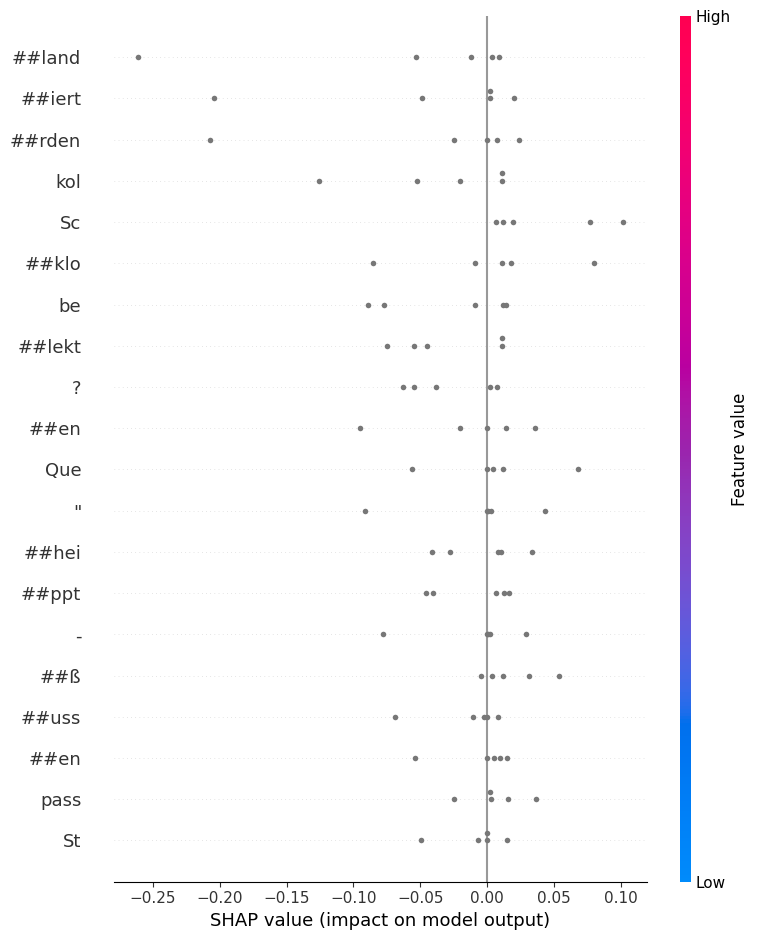


Force Plot for Sample 1: Was ist nur mit diesem Scheißland passiert? Alle werden kollektiv bekloppt und teilen Querdenen-Stuss. Erst meinen "Klatschen für die Pflegekräfte" wäre hilfreich und jetzt allen Pflegern und Medizinern so ins Gesicht spucken. Schämt euch!#allenichtganzdicht #allesdichtmachen


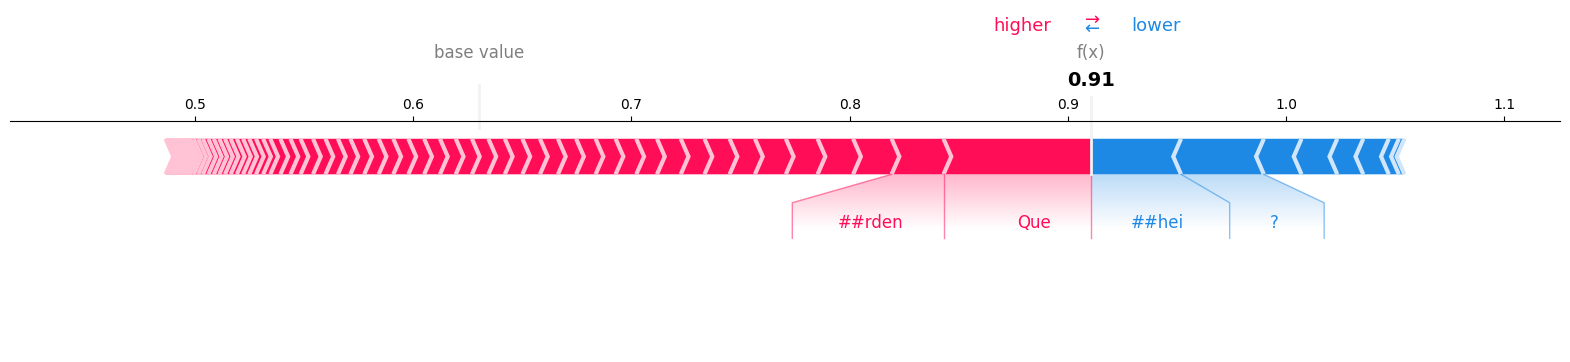


Force Plot for Sample 2:   haben schlimme Fehler begangen. Sowohl bei den Obduktionen als auch bei der Impfstoffzulassung etc. Aber gerade am Beispiel Püschel: Was haben die Querdenker draus gemacht? Die Patienten starben an Thrombosen und nicht an Covid. So dumm muss man schon sein...


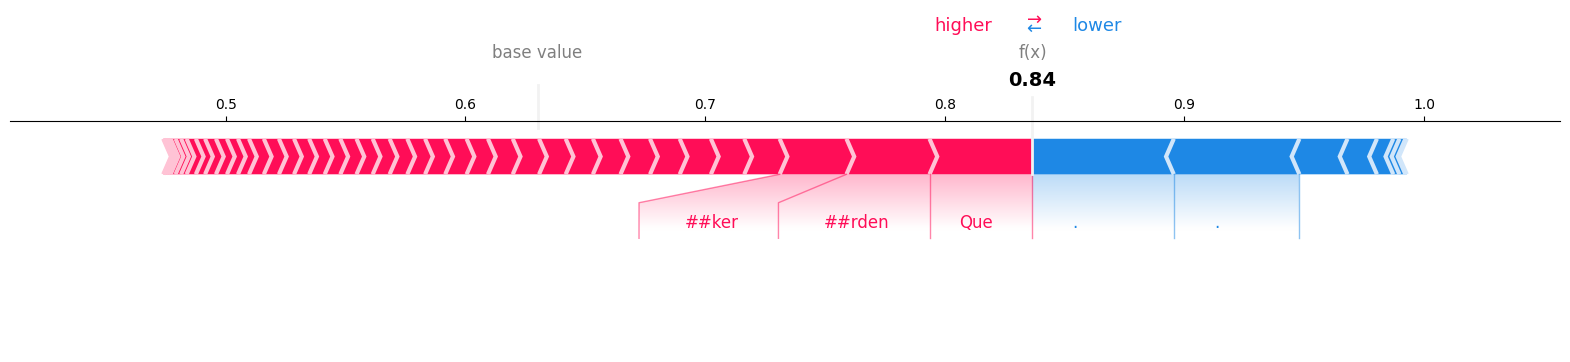


Force Plot for Sample 3:  Ich denke oft noch an den Fürsten aus Regensburg zurück...der bekam in null komma nix seine Transplantationen.Ein Schelm wer schlechtes dabei denkt


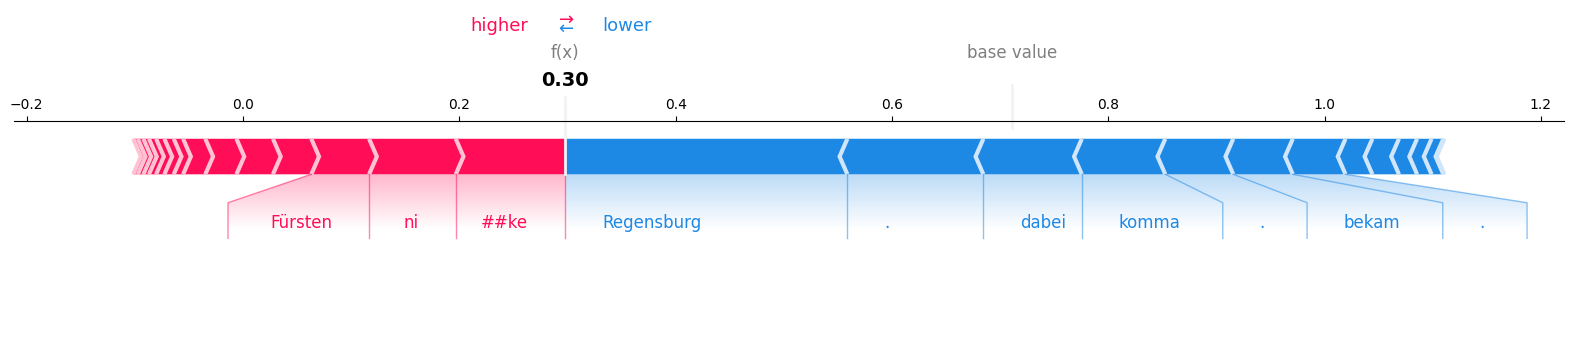


Force Plot for Sample 4: Auch durch eure Zensur in Deutschland werdet ihr nichts ändern. Wie sehr in Deutschland zensiert wird kann ich hier im Ausland sehr gut erkennen. |LBR| #illner


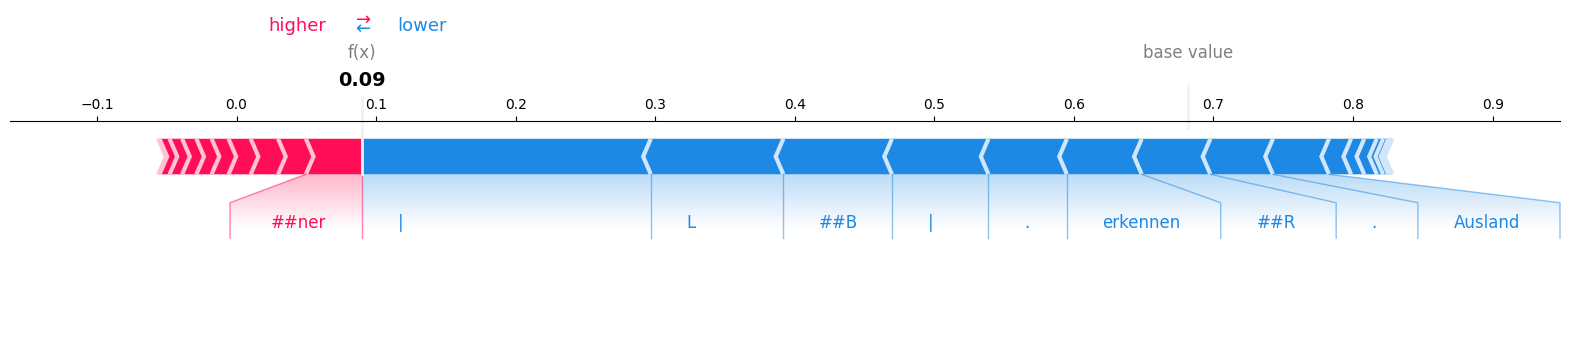


Force Plot for Sample 5: Also ich lache nicht über England, eher über die EU die nur scheinbar so vereint ist.


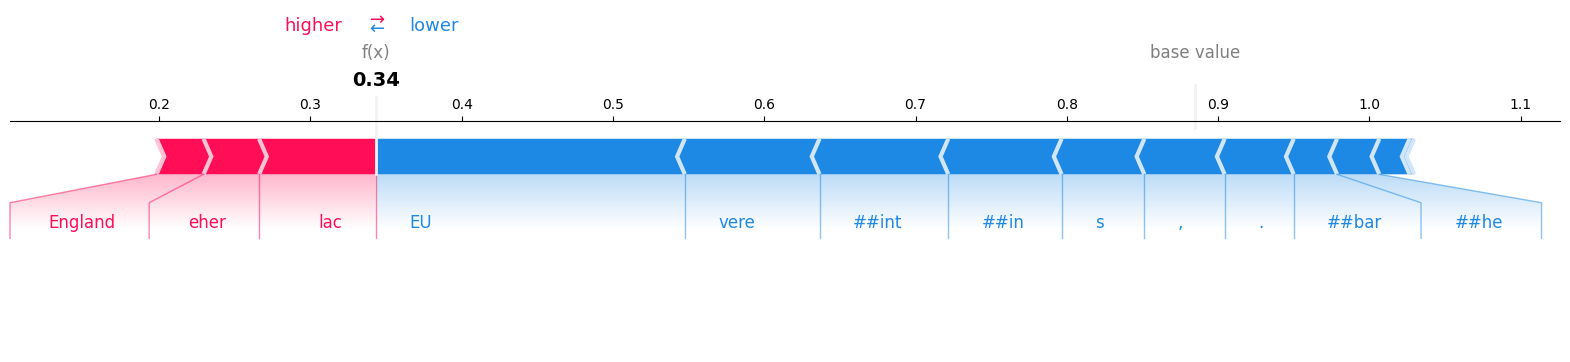

In [ ]:
# Install required libraries
!pip install shap transformers torch

# Import required libraries
import shap
import numpy as np
from transformers import BertTokenizerFast, BertForSequenceClassification
import torch
from itertools import zip_longest

# Load the trained model and tokenizer
model = BertForSequenceClassification.from_pretrained("./saved_model")
tokenizer = BertTokenizerFast.from_pretrained("./saved_model")
model.to("cuda" if torch.cuda.is_available() else "cpu")

# Define predict_proba for SHAP
def predict_proba(texts):
    if isinstance(texts, str):
        texts = [texts]
    elif isinstance(texts, list) and all(isinstance(t, list) for t in texts):
        texts = [" ".join(tokens) for tokens in texts]
    elif isinstance(texts, np.ndarray):
        texts = texts.tolist()
    elif not isinstance(texts, list) or not all(isinstance(t, str) for t in texts):
        raise ValueError(f"Unexpected input format: {type(texts)}")

    inputs = tokenizer(
        texts, truncation=True, max_length=128, padding=True, return_tensors="pt"
    ).to("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.nn.functional.softmax(logits, dim=1)
    return probs.cpu().numpy()

# Initialize SHAP Explainer with Text Masker
masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_proba, masker)

# Select random sample texts from the test dataset
num_samples_to_show = 5  # Show more samples (adjust as needed)

# Sample more texts from the dataset
sample_texts = test_df.sample(num_samples_to_show, random_state=42)["text"].tolist()

print("Sample Texts from Dataset:")
for i, text in enumerate(sample_texts, 1):
    print(f"Sample {i}: {text}")

# Compute SHAP values
shap_values = explainer(sample_texts)

# Extract tokens and normalize SHAP values
tokens_list = [
    tokenizer.convert_ids_to_tokens(tokenizer(sample, truncation=True)["input_ids"])
    for sample in sample_texts
]
max_len = max(len(value.values) for value in shap_values)
normalized_shap_values = [
    np.pad(value.values[:, 1], (0, max_len - len(value.values[:, 1])), constant_values=0)
    for value in shap_values
]

# Define stop words
german_stopwords = {
    'aber', 'alle', 'allem', 'allen', 'aller', 'alles', 'als', 'also', 'am', 'an', 'andere',
    'anderen', 'andern', 'anders', 'auch', 'auf', 'aus', 'bei', 'bin', 'bis', 'bist', 'da',
    'damit', 'dann', 'der', 'den', 'des', 'dem', 'die', 'das', 'dass', 'derselbe', 'derselben',
    'denselben', 'desselben', 'demselben', 'dieselbe', 'dieselben', 'dasselbe', 'dazu', 'dein',
    'deine', 'deinem', 'deinen', 'deiner', 'deines', 'denn', 'derer', 'dessen', 'dich', 'dir',
    'du', 'dies', 'diese', 'diesem', 'diesen', 'dieser', 'dieses', 'doch', 'dort', 'durch',
    'ein', 'eine', 'einem', 'einen', 'einer', 'eines', 'einig', 'einige', 'einigem', 'einigen',
    'einiger', 'einiges', 'einmal', 'er', 'ihn', 'ihm', 'es', 'etwas', 'euer', 'eure', 'eurem',
    'euren', 'eurer', 'eures', 'für', 'gegen', 'gewesen', 'hab', 'habe', 'haben', 'hat', 'hatte',
    'hatten', 'hier', 'hin', 'hinter', 'ich', 'mich', 'mir', 'ihr', 'ihre', 'ihrem', 'ihren',
    'ihrer', 'ihres', 'euch', 'im', 'in', 'indem', 'ins', 'ist', 'jede', 'jedem', 'jeden', 'jeder',
    'jedes', 'jene', 'jenem', 'jenen', 'jener', 'jenes', 'jetzt', 'kann', 'kein', 'keine', 'keinem',
    'keinen', 'keiner', 'keines', 'können', 'könnte', 'machen', 'man', 'manche', 'manchem', 'manchen',
    'mancher', 'manches', 'mein', 'meine', 'meinem', 'meinen', 'meiner', 'meines', 'mit', 'muss',
    'musste', 'nach', 'nicht', 'nichts', 'noch', 'nun', 'nur', 'ob', 'oder', 'ohne', 'sehr', 'sein',
    'seine', 'seinem', 'seinen', 'seiner', 'seines', 'selbst', 'sich', 'sie', 'ihnen', 'sind',
    'so', 'solche', 'solchem', 'solchen', 'solcher', 'solches', 'soll', 'sollte', 'sondern',
    'sonst', 'über', 'um', 'und', 'uns', 'unse', 'unsem', 'unsen', 'unser', 'unses', 'unter',
    'viel', 'vom', 'von', 'vor', 'war', 'waren', 'warst', 'was', 'weg', 'weil', 'weiter', 'welche',
    'welchem', 'welchen', 'welcher', 'welches', 'wenn', 'werde', 'werden', 'wie', 'wieder', 'will',
    'wir', 'wird', 'wirst', 'wo', 'wollen', 'wollte', 'während', 'würde', 'würden', 'zu', 'zum',
    'zur', 'zwar', 'zwischen', 'über'
}

# Define function to filter stop words
def filter_stopwords_and_shap(tokens, shap_values, stopwords):
    filtered_tokens = []
    filtered_shap_values = []

    for token, shap_value in zip(tokens, shap_values):
        # Check if the base word (if available) is in stopwords
        base_token = token.split("##")[0].lower()  # Get base word without subword prefixes
        if base_token not in stopwords:
            filtered_tokens.append(token)
            filtered_shap_values.append(shap_value)

    return filtered_tokens, filtered_shap_values

# Apply filtering to tokens and SHAP values
filtered_shap_results = []
for tokens, shap_value in zip(tokens_list, shap_values):
    filtered_tokens, filtered_shap_values = filter_stopwords_and_shap(
        tokens, shap_value.values[:, 1], german_stopwords
    )
    filtered_shap_results.append((filtered_tokens, filtered_shap_values))

# Pad SHAP values to equal length for visualization
max_len_filtered = max(len(result[0]) for result in filtered_shap_results)

# Pad tokens and SHAP values for visualization
padded_tokens = [
    tokens + ['[PAD]'] * (max_len_filtered - len(tokens))
    for tokens, _ in filtered_shap_results
]
padded_shap_values = [
    np.pad(values, (0, max_len_filtered - len(values)), constant_values=0)
    for _, values in filtered_shap_results
]

# Print Tokens and SHAP Values for Each Sample
print("\nFiltered Tokens and Corresponding SHAP Values:")
for i, (text, result) in enumerate(zip(sample_texts, filtered_shap_results), start=1):
    filtered_tokens, filtered_values = result
    print(f"\nSample {i}: {text}")
    for token, value in zip(filtered_tokens, filtered_values):
        print(f"Token: {token}, SHAP Value: {value:.4f}")

# SHAP Summary Plot
shap.initjs()
shap.summary_plot(
    shap_values=np.array(padded_shap_values),
    features=np.array(padded_tokens),
    feature_names=padded_tokens[0]
)

# SHAP Force Plot for Individual Samples
for i, (text, result) in enumerate(zip(sample_texts, filtered_shap_results)):
    filtered_tokens, filtered_values = result
    print(f"\nForce Plot for Sample {i + 1}: {text}")

    # Pad tokens and SHAP values for the force plot
    padded_tokens = filtered_tokens + ['[PAD]'] * (max_len_filtered - len(filtered_tokens))
    padded_values = np.pad(filtered_values, (0, max_len_filtered - len(filtered_values)), constant_values=0)

    shap.force_plot(
        base_value=shap_values[i].base_values[1],  # Ensure you're using base_value properly
        shap_values=padded_values,
        features=padded_tokens,
        matplotlib=True
    )
